In [ ]:
# Zayaan Rahman and Syed Ali
# 4/21/2025
# NLP Final Project Code
# this was originally a python notebook

In [ ]:
!pip install datasets scikit-learn scipy gensim umap-learn tqdm -q

In [ ]:
import re
import json
import math
import time
import random
import logging
import warnings

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from collections import Counter, defaultdict
from tqdm.auto import tqdm

from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import umap
from gensim.models import Word2Vec
from scipy import stats


warnings.filterwarnings('ignore')
logging.disable(logging.INFO)

In [ ]:
FIELDS = ["rating", "title", "text", "asin", "parent_asin",
          "user_id", "timestamp", "helpful_vote", "verified_purchase"]

def load_amazon_reviews(cat="Amazon_Fashion", max_rev=None, min_length=3):
    # streams reviews from HuggingFace, returns cleaned dataframe

    ds = load_dataset(
        "json",
        data_files=f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{cat}.jsonl",
        split="train",
        streaming=True,
    )

    records = []

    with tqdm(total=max_rev, desc=cat) as pbar:

        for record in ds:
            if len((record.get("text") or "").strip()) < min_length:
                continue

            row = {f: record.get(f) for f in FIELDS}
            records.append(row)
            pbar.update(1)
            if max_rev and len(records) >= max_rev:
                break

    df = pd.DataFrame(records)

    df["timestamp_sec"] = df["timestamp"] / 1000
    df["rating_int"] = df["rating"].astype(int)
    df["helpful_vote"] = df["helpful_vote"].fillna(0).astype(int)

    return df

In [ ]:
TOKEN_PATTERN = re.compile(r"""
    <[^>]+>
    | \$\d+(?:\.\d+)?
    | \d+(?:\.\d+)?
    | [a-z]+(?:['\u2018\u2019][a-z]+)*
    | [a-z]+-[a-z]+
""", re.VERBOSE | re.IGNORECASE)

def tokenize(text):
    # returns lowercase token list, empty list for bad input

    if not isinstance(text, str) or not text.strip():
        return []

    return [t.lower() for t in TOKEN_PATTERN.findall(text) if not t.startswith('<')] # get rid of html


def count_tokens(df):
    # total token count across all reviews in a dataframe
    return sum(len(tokenize(t)) for t in tqdm(df["text"].dropna(), desc="counting tokens"))

In [ ]:
def print_dataset_stats(df, total_tokens):
    # prints corpus overview; size, users, dates, tokens, ratings, user thresholds

    dates = pd.to_datetime(df["timestamp_sec"], unit="s")
    counts = df.groupby("user_id").size()

    print(f"reviews : {len(df):,}")
    print(f"users   : {df['user_id'].nunique():,}")
    print(f"dates   : {dates.min().date()} to {dates.max().date()}")
    print(f"tokens  : {total_tokens:,}")
    print(f"ratings: {df['rating_int'].value_counts().sort_index().to_dict()}")

    print("\nusers by min review count:")

    for t in [1, 2, 5, 10, 20, 50]:

        n_users = (counts >= t).sum()
        n_revs = counts[counts >= t].sum()
        print(f"  >= {t:2d} : {n_users:6,} users  {n_revs:8,} reviews")

amazon_df = load_amazon_reviews()
total_tokens = count_tokens(amazon_df)
print_dataset_stats(amazon_df, total_tokens)

Amazon_Fashion: 0it [00:00, ?it/s]

counting tokens:   0%|          | 0/2492799 [00:00<?, ?it/s]

reviews  : 2,492,799
users    : 2,029,583
dates    : 2002-05-07 to 2023-09-11
tokens   : 67,991,970
ratings  : {1: 302814, 2: 173191, 3: 244590, 4: 351153, 5: 1421051}

users by min review count:
  >=  1 : 2,029,583 users  2,492,799 reviews
  >=  2 : 297,507 users   760,723 reviews
  >=  5 : 15,421 users   114,784 reviews
  >= 10 :  2,089 users    35,367 reviews
  >= 20 :    414 users    14,426 reviews
  >= 50 :     49 users     4,036 reviews


In [ ]:
# labels users by activity status, assigns career stage bins, splits early/late career

def compute_user_lifespans(df, min_reviews=5, inactivity_gap_days=365, active_window_days=365):
    # labels each user as departed/active/ambiguous based on inactivity before cutoff
    # returns user_df and df with date column added

    df = df.copy()
    df["date"] = pd.to_datetime(df["timestamp_sec"], unit="s", utc=True)

    counts = df.groupby("user_id").size()
    df = df[df["user_id"].isin(counts[counts >= min_reviews].index)]

    grp = df.groupby("user_id")

    user_df = pd.DataFrame({
        "n_reviews":  grp.size(),
        "first_date": grp["date"].min(),
        "last_date":  grp["date"].max(),
        "avg_rating": grp["rating_int"].mean(),
    }).reset_index()

    user_df["lifespan_days"] = (
        (user_df["last_date"] - user_df["first_date"]).dt.total_seconds() / 86400
    )

    cutoff = df["date"].max()
    active_cutoff = cutoff - pd.Timedelta(days=active_window_days)

    user_df["departed"] = (
        (cutoff - user_df["last_date"]).dt.total_seconds() / 86400

    ) >= inactivity_gap_days
    user_df.loc[user_df["last_date"] >= active_cutoff, "departed"] = None

    return user_df, df


def attach_life_stage(df, user_df, bins=10):
    # assigns each departed user's review a career stage bin (1=earliest, bins=latest)
    # returns df_dep with life_stage_bin column added

    departed_ids = set(user_df[user_df["departed"] == True]["user_id"])
    df_dep = df[df["user_id"].isin(departed_ids)].copy()
    df_dep = df_dep.sort_values(["user_id", "date"])

    df_dep["review_rank"] = df_dep.groupby("user_id").cumcount() + 1
    n_map = user_df.set_index("user_id")["n_reviews"]
    df_dep["n_total"] = df_dep["user_id"].map(n_map)
    df_dep["life_stage_pct"] = df_dep["review_rank"] / df_dep["n_total"]

    df_dep["life_stage_bin"] = pd.cut(
        df_dep["life_stage_pct"],
        bins=np.linspace(0, 1, bins + 1),
        labels=range(1, bins + 1),
        include_lowest=True
    ).astype(float)

    return df_dep


def get_early_late_career(df_dep, min_reviews=10):
    # splits into early career (bins 1-4) and late career (bins 7-10)
    # returns early_career, late_career, list of eligible user ids

    counts = df_dep.groupby("user_id").size()
    eligible = counts[counts >= min_reviews].index

    df = df_dep[df_dep["user_id"].isin(eligible)]

    early_career = df[df["life_stage_bin"] <= 4].copy()
    late_career = df[df["life_stage_bin"] >= 7].copy()

    return early_career, late_career, list(eligible)


def print_lifespan_stats(user_df, early_career, late_career, eligible_users):
    # summary of the departed user population and early/late career split

    dep = user_df[user_df["departed"] == True]

    print(f"departed users   : {len(dep):,}")
    print(f"eligible users   : {len(eligible_users):,}  (>= 10 reviews)")
    print(f"early career     : {len(early_career):,} reviews  (bins 1-4)")
    print(f"late career      : {len(late_career):,} reviews  (bins 7-10)")
    print(f"avg early/user   : {len(early_career) / len(eligible_users):.1f}")
    print(f"avg late/user    : {len(late_career)  / len(eligible_users):.1f}")

    ls = dep["lifespan_days"]

    print(f"\nlifespan (days)  : mean={ls.mean():.0f}  median={ls.median():.0f}  std={ls.std():.0f}")

In [ ]:
# splits the full dataset into early and late calendar year windows

def split_by_era(df, early_range=(2014, 2016), late_range=(2020, 2022)):
    # returns early_era and late_era excluding buffer years

    year = pd.to_datetime(df["timestamp_sec"], unit="s").dt.year

    early_era = df[year.between(*early_range)].copy()
    late_era = df[year.between(*late_range)].copy()

    return early_era, late_era


def print_temporal_stats(early_era, late_era):
    # review counts, user counts, and date ranges for each window

    for label, df in [("early era (2014-2016)", early_era), ("late era (2020-2022)", late_era)]:

        dates = pd.to_datetime(df["timestamp_sec"], unit="s")
        print(f"{label}")
        print(f"  reviews : {len(df):,}  |  users : {df['user_id'].nunique():,}")
        print(f"  dates   : {dates.min().date()} to {dates.max().date()}")
        print(f"  ratings : {df['rating_int'].value_counts().sort_index().to_dict()}")

In [ ]:
# runs the full pipeline, creates dfs for downstream

user_df, df_filtered = compute_user_lifespans(amazon_df)
df_dep = attach_life_stage(df_filtered, user_df)
early_career, late_career, eligible_users = get_early_late_career(df_dep)
print_lifespan_stats(user_df, early_career, late_career, eligible_users)

print()

early_era, late_era = split_by_era(amazon_df)
print_temporal_stats(early_era, late_era)

# pre-tokenize once here
for df in [df_dep, early_career, late_career, early_era, late_era]:
    df["tokens"] = df["text"].apply(tokenize)

departed users   : 13,814
eligible users   : 1,682  (>= 10 reviews)
early career     : 9,932 reviews  (bins 1-4)
late career      : 11,031 reviews  (bins 7-10)
avg early/user   : 5.9
avg late/user    : 6.6

lifespan (days)  : mean=1000  median=911  std=706

early era (2014-2016)
  reviews : 474,927  |  users : 412,194
  dates   : 2014-01-01 to 2016-12-31
  ratings : {1: 42986, 2: 29815, 3: 48151, 4: 81887, 5: 272088}
late era (2020-2022)
  reviews : 793,033  |  users : 704,295
  dates   : 2020-01-01 to 2022-12-31
  ratings : {1: 118481, 2: 58268, 3: 76596, 4: 91504, 5: 448184}


In [ ]:
# positive z = distinctive to df_a, negative z = distinctive to df_b

def compute_dla(df_a, df_b, min_count=3):
    # computes log-odds z-score for every word in the joint vocabulary
    # returns dataframe sorted by z-score descending

    tokens_a = [tok for tokens in df_a["tokens"].dropna() for tok in tokens]
    tokens_b = [tok for tokens in df_b["tokens"].dropna() for tok in tokens]

    count_a, count_b = Counter(tokens_a), Counter(tokens_b)

    n_a, n_b = len(tokens_a), len(tokens_b)
    alpha_0 = n_a + n_b

    rows = []

    for w in set(count_a) | set(count_b):

        f_a, f_b = count_a.get(w, 0), count_b.get(w, 0)
        alpha_w = f_a + f_b
        if alpha_w < min_count:
            continue

        log_a = np.log((f_a + alpha_w) / (n_a + alpha_0 - f_a - alpha_w))
        log_b = np.log((f_b + alpha_w) / (n_b + alpha_0 - f_b - alpha_w))
        delta = log_a - log_b
        sigma = np.sqrt(1 / (f_a + alpha_w) + 1 / (f_b + alpha_w))

        rows.append({"word": w, "z_score": delta / sigma,
                     "count_a": f_a, "count_b": f_b})

    return pd.DataFrame(rows).sort_values("z_score", ascending=False).reset_index(drop=True)


def print_top_words(dla_df, label_a, label_b, n=50):
    # prints top n words for each side with z-scores and counts

    print(f"top {n} words distinctive to {label_a}:")
    print(dla_df.head(n)[["word", "z_score", "count_a", "count_b"]].to_string(index=False))
    print(f"\ntop {n} words distinctive to {label_b}:")

    print(dla_df.tail(n).sort_values("z_score")[["word", "z_score", "count_a", "count_b"]].to_string(index=False))


def plot_dla(dla_df, label_a, label_b, n=20, filename=None):
    # side-by-side bar charts of top n words for each side

    top_a = dla_df.head(n)
    top_b = dla_df.tail(n).sort_values("z_score")

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].barh(top_a["word"], top_a["z_score"], color="#3498DB", alpha=0.85)
    axes[0].set_title(f"distinctive to: {label_a}", fontweight="bold")
    axes[0].set_xlabel("z-score (log-odds)")

    axes[1].barh(top_b["word"], top_b["z_score"], color="#E74C3C", alpha=0.85)
    axes[1].set_title(f"distinctive to: {label_b}", fontweight="bold")
    axes[1].set_xlabel("z-score (log-odds)")
    axes[1].invert_xaxis()

    plt.suptitle(f"DLA: {label_a} vs {label_b}\n(Monroe et al. 2008 log-odds)",
                 fontsize=13, fontweight="bold", y=1.02)

    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")

    plt.show()


temporal DLA
top 50 words distinctive to early era (2014-2016):
      word    z_score  count_a  count_b
        34 123.501013    37992     2839
    honest  60.622783     9393      808
    review  58.437889    16041     5757
  discount  50.078637     5874      263
  unbiased  46.245266     4609       23
  exchange  45.662217     6517     1166
      it's  44.183321    53756    52002
    wallet  42.857938     8649     3111
discounted  36.957547     3062       73
  received  36.542435    19499    15283
       i'm  35.518033    32623    31006
       bag  34.991110    18774    15005
     price  34.833984    38485    38575
  bracelet  31.227879    10579     7238
  necklace  30.646653    12186     9080
        it  30.488348   399546   557755
   leather  30.171072     9174     6038
     cards  29.971394     4125     1439
   product  29.721353    33983    35602
     purse  29.530976     7191     4204
 beautiful  27.881457    28116    29053
         i  26.902884   520617   745815
     don't  26.6

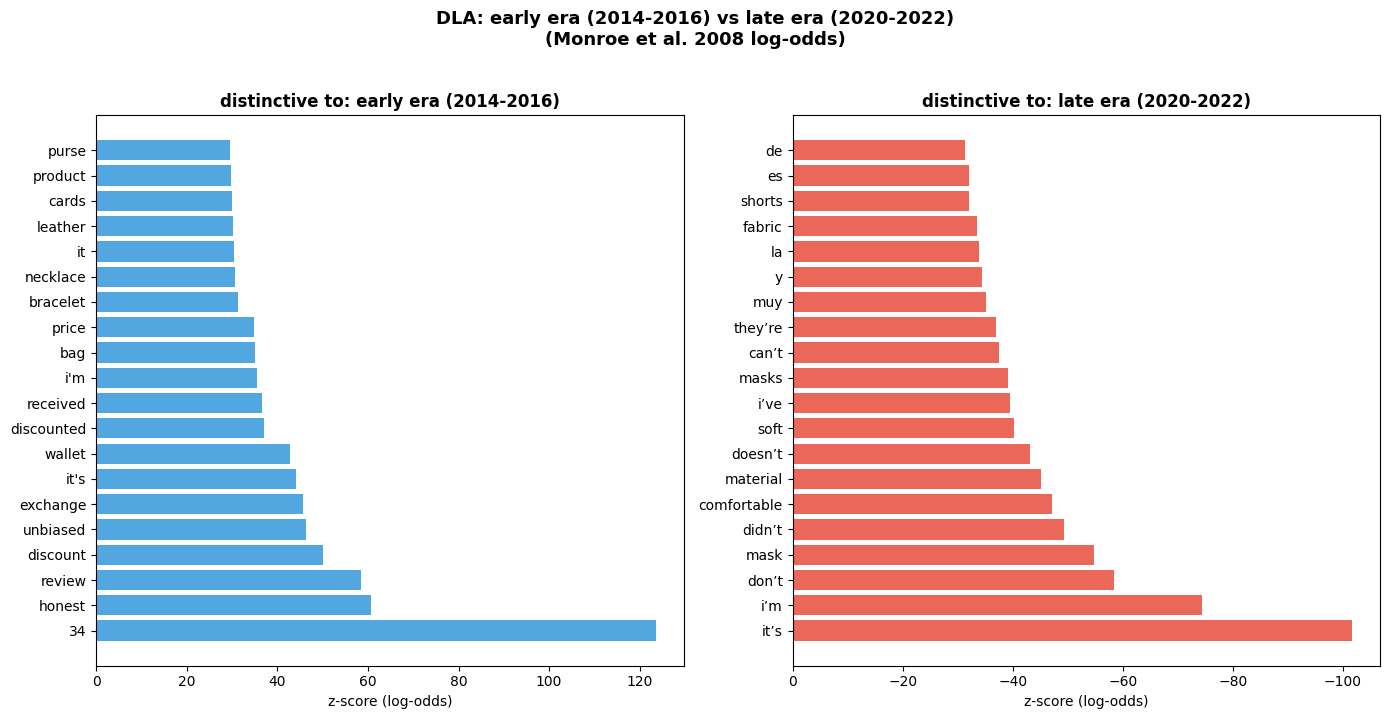


lifespan DLA
top 50 words distinctive to early career:
      word  z_score  count_a  count_b
        34 8.663854     1282      655
     scarf 5.880803      381      154
       hat 5.022843      490      264
      belt 5.005989      522      289
   leather 3.918571      457      285
    honest 3.806357      456      289
  unbiased 3.435148      273      157
        it 3.187970    16164    15760
      will 3.122829     2033     1767
       app 3.015788       35        3
  discount 3.000712      215      125
  exchange 2.999599      274      172
    buckle 2.937071      115       52
     watch 2.836588      440      318
         a 2.659202    20039    19845
     socks 2.589682      757      615
     slots 2.580881       60       21
       i'm 2.538135     1467     1285
      ties 2.474443      132       74
      give 2.466897      455      348
    wallet 2.396202      185      118
    vendor 2.363584       34        8
   product 2.346598      786      657
      brim 2.277261       60    

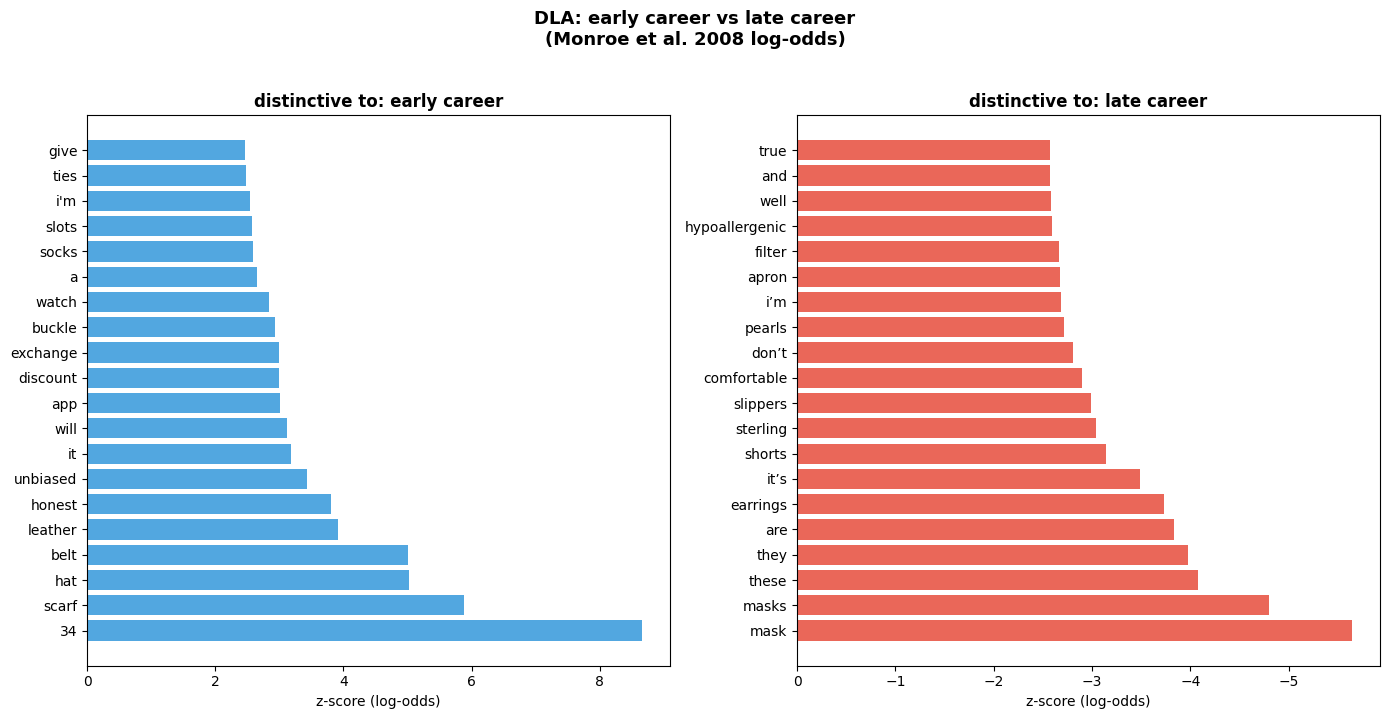

In [ ]:
# computes and visualizes DLA for both temporal and lifespan splits

print("temporal DLA")
dla_temporal = compute_dla(early_era, late_era)
print_top_words(dla_temporal, "early era (2014-2016)", "late era (2020-2022)")
plot_dla(dla_temporal, "early era (2014-2016)", "late era (2020-2022)",
         filename="dla_temporal.png")

print("\nlifespan DLA")
dla_lifespan = compute_dla(early_career, late_career)
print_top_words(dla_lifespan, "early career", "late career")
plot_dla(dla_lifespan, "early career", "late career",
         filename="dla_lifespan.png")

In [ ]:
# TF-IDF logistic regression

def build_classification_dataset(df_a, df_b, max_per_class=50000, seed=42):
    # balances classes by sampling up to max_per_class from each
    # joins pre-tokenized token lists to strings for TF-IDF
    # returns stratified 75/25 train/test split

    # need max per class due to RAM limitations


    df_a = df_a[df_a["tokens"].apply(len) > 0]
    df_b = df_b[df_b["tokens"].apply(len) > 0]

    n = min(len(df_a), len(df_b), max_per_class)

    texts_a = df_a.sample(n, random_state=seed)["tokens"].apply(" ".join).tolist()
    texts_b = df_b.sample(n, random_state=seed)["tokens"].apply(" ".join).tolist()

    X = np.array(texts_a + texts_b)
    y = np.array([0] * n + [1] * n)

    return train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)


def run_tfidf_classifier(X_train, X_test, y_train, y_test):
    # vectorizes with TF-IDF, trains logistic regression, returns model and metrics

    vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 1), sublinear_tf=True)
    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)

    clf = LogisticRegression(solver="saga", max_iter=1000, C=1.0,
                             n_jobs=-1, random_state=42)
    clf.fit(X_train_vec, y_train)

    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred, average="macro")

    return clf, vec, y_pred, {"acc": acc, "f1": f1}


def print_classification_results(y_test, y_pred, label_a, label_b):
    # prints per-class and overall classification metrics

    print(classification_report(y_test, y_pred,
                                target_names=[label_a, label_b], digits=3))


def plot_top_features(clf, vec, label_a, label_b, n=15, filename=None):
    # bar charts of top n TF-IDF features for each class
    # positive coefficients predict label_b, negative predict label_a

    coefs = clf.coef_[0]
    names = vec.get_feature_names_out()

    top_a = [(names[i], coefs[i]) for i in np.argsort(coefs)[:n]]
    top_b = [(names[i], coefs[i]) for i in np.argsort(coefs)[-n:][::-1]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    words_a, scores_a = zip(*top_a)
    axes[0].barh(words_a[::-1], scores_a[::-1], color="#3498DB", alpha=0.85)
    axes[0].set_title(f"top features: {label_a}", fontweight="bold")
    axes[0].set_xlabel("logistic regression coefficient")

    words_b, scores_b = zip(*top_b)
    axes[1].barh(words_b[::-1], scores_b[::-1], color="#E74C3C", alpha=0.85)
    axes[1].set_title(f"top features: {label_b}", fontweight="bold")
    axes[1].set_xlabel("logistic regression coefficient")

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


temporal (early era vs late era)
              precision    recall  f1-score   support

   early era      0.661     0.660     0.660     12500
    late era      0.660     0.661     0.661     12500

    accuracy                          0.660     25000
   macro avg      0.660     0.660     0.660     25000
weighted avg      0.660     0.660     0.660     25000



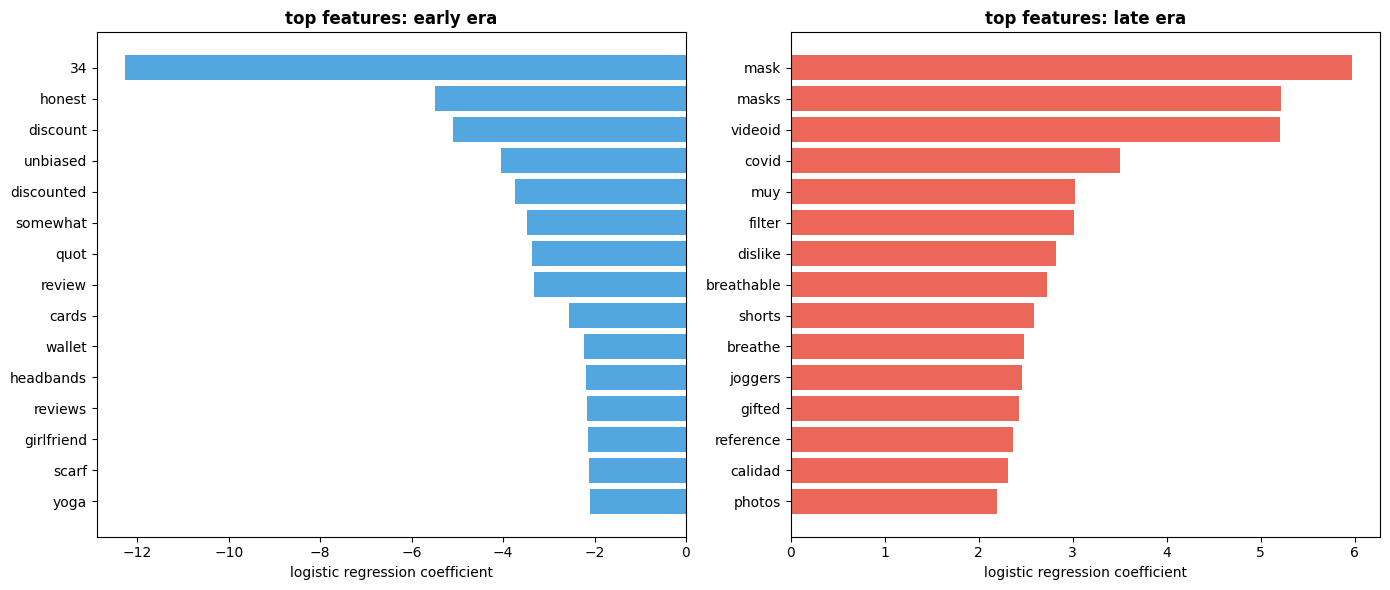

lifespan (early career vs late career)
              precision    recall  f1-score   support

early career      0.560     0.559     0.560      2483
 late career      0.560     0.560     0.560      2483

    accuracy                          0.560      4966
   macro avg      0.560     0.560     0.560      4966
weighted avg      0.560     0.560     0.560      4966



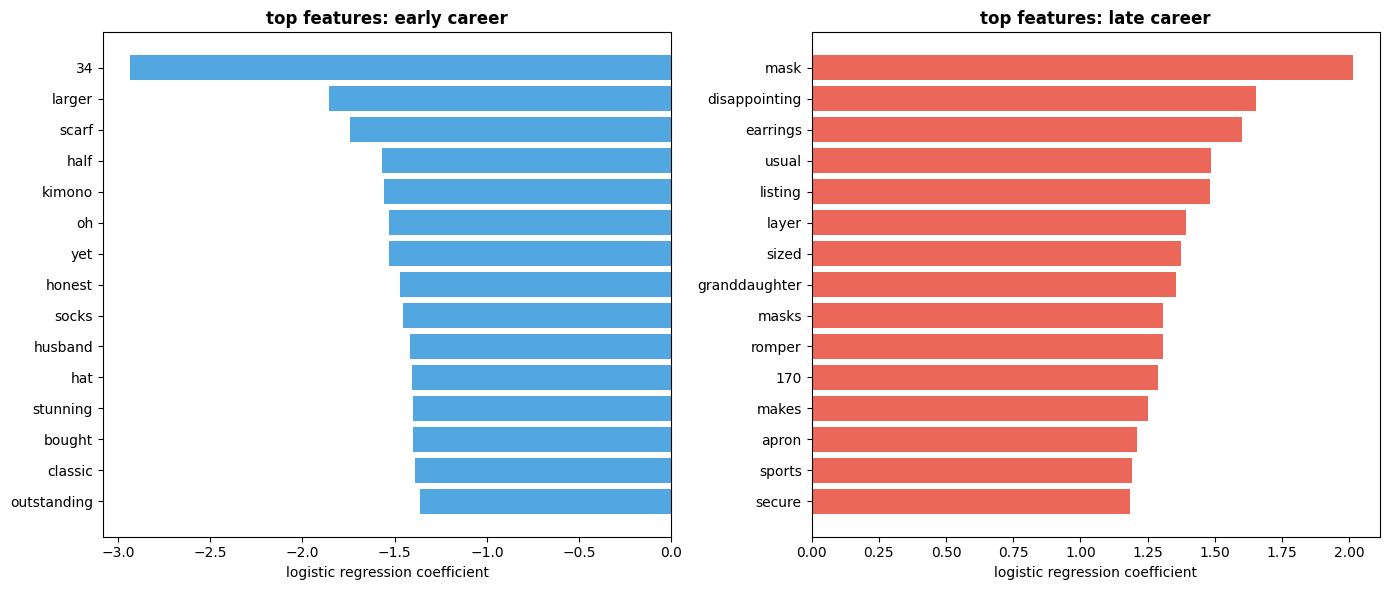


task                                 accuracy  macro f1
-------------------------------------------------------
temporal                                0.660     0.660
lifespan                                0.560     0.560
chance baseline                         0.500     0.500


In [ ]:
# runs the same TF-IDF logistic regression pipeline for temporal and lifespan tasks

X_train, X_test, y_train, y_test = build_classification_dataset(early_era, late_era)
clf_temp, vec_temp, y_pred_temp, metrics_temp = run_tfidf_classifier(
    X_train, X_test, y_train, y_test)
print("temporal (early era vs late era)")
print_classification_results(y_test, y_pred_temp, "early era", "late era")
plot_top_features(clf_temp, vec_temp, "early era", "late era",
                  filename="clf_temporal_features.png")

X_train, X_test, y_train, y_test = build_classification_dataset(early_career, late_career)
clf_life, vec_life, y_pred_life, metrics_life = run_tfidf_classifier(
    X_train, X_test, y_train, y_test)
print("lifespan (early career vs late career)")
print_classification_results(y_test, y_pred_life, "early career", "late career")
plot_top_features(clf_life, vec_life, "early career", "late career",
                  filename="clf_lifespan_features.png")

print(f"\n{'task':<35} {'accuracy':>9} {'macro f1':>9}")
print("-" * 55)
print(f"{'temporal':35} {metrics_temp['acc']:9.3f} {metrics_temp['f1']:9.3f}")
print(f"{'lifespan':35} {metrics_life['acc']:9.3f} {metrics_life['f1']:9.3f}")
print(f"{'chance baseline':35} {'0.500':>9} {'0.500':>9}")

In [ ]:
# bigram LM with Laplace smoothing — used to measure how surprising late
# reviews are to a model trained on early reviews
class BigramLM:

    def __init__(self, alpha=0.5):
        self.alpha = alpha
        self.bigram_counts = Counter()
        self.unigram_counts = Counter()
        self.vocab = set()

    def train(self, token_lists):
        # builds bigram and unigram counts from a list of token lists

        for tokens in token_lists:

            if len(tokens) < 2:
                continue
            for tok in tokens:
                self.unigram_counts[tok] += 1
                self.vocab.add(tok)
            for i in range(len(tokens) - 1):
                self.bigram_counts[(tokens[i], tokens[i + 1])] += 1

    def log_prob(self, w1, w2):
        # smoothed log probability of bigram (w1, w2)

        V = len(self.vocab)
        num = self.bigram_counts.get((w1, w2), 0) + self.alpha
        den = self.unigram_counts.get(w1, 0) + self.alpha * V
        return math.log(num / den) if V > 0 else -math.log(1e-10)

    def perplexity(self, token_lists):
        # corpus level perplexity over a list of token lists

        total_lp, n_bigrams = 0.0, 0
        for tokens in token_lists:
            if len(tokens) < 2:
                continue
            for i in range(len(tokens) - 1):
                total_lp  += self.log_prob(tokens[i], tokens[i + 1])
                n_bigrams += 1

        if n_bigrams == 0:
            return float("inf")
        return math.exp(-total_lp / n_bigrams)

    def perplexity_per_doc(self, token_lists):
        # per-document perplexity list for statistical testing

        return [self.perplexity([t]) for t in token_lists if len(t) >= 2]

In [ ]:
# trains bigram LM on early reviews, evaluates on held-out early (self) and late

def compute_perplexity_analysis(df_early, df_late, train_frac=0.75, seed=42):

    # returns self_ppls, late_ppls, and ppl ratio (late/self)
    # higher ratio = late reviews are more surprising to the early model = more drift

    early_toks = [t for t in df_early["tokens"] if len(t) >= 2]
    late_toks = [t for t in df_late["tokens"]  if len(t) >= 2]

    rng = random.Random(seed)
    rng.shuffle(early_toks)
    n_train = int(len(early_toks) * train_frac)
    train_toks = early_toks[:n_train]
    self_toks = early_toks[n_train:]

    print(f"training: {len(train_toks):,}  self test: {len(self_toks):,}  late test: {len(late_toks):,}")

    lm = BigramLM()
    lm.train(train_toks)

    self_ppls = pd.Series(lm.perplexity_per_doc(self_toks))
    late_ppls = pd.Series(lm.perplexity_per_doc(late_toks))

    ratio = late_ppls.median() / self_ppls.median()

    stat, p = stats.mannwhitneyu(late_ppls, self_ppls, alternative="greater")

    print(f"median self PPL : {self_ppls.median():.1f}")
    print(f"median late PPL : {late_ppls.median():.1f}")
    print(f"ratio           : {ratio:.3f}")
    print(f"mann-whitney    : p={p:.4f}  ({'significant' if p < 0.05 else 'not significant'} at alpha=0.05)")

    return self_ppls, late_ppls, ratio


def plot_perplexity(self_ppls, late_ppls, label_early, label_late, filename=None):
    # overlapping histograms of self vs late perplexity, clipped at 95th percentile

    clip = max(self_ppls.quantile(0.95), late_ppls.quantile(0.95))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(self_ppls.clip(upper=clip), bins=40, alpha=0.6, color="#2ECC71",
            label=f"{label_early}  median={self_ppls.median():.1f}")
    ax.hist(late_ppls.clip(upper=clip), bins=40, alpha=0.6, color="#E74C3C",
            label=f"{label_late}  median={late_ppls.median():.1f}")

    ax.set_xlabel("perplexity (lower = more predictable to early model)")
    ax.set_ylabel("reviews")
    ax.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

temporal perplexity
training: 343,488  self test: 114,497  late test: 778,210
median self PPL : 284.2
median late PPL : 358.5
ratio           : 1.261
mann-whitney    : p=0.0000  (significant at alpha=0.05)


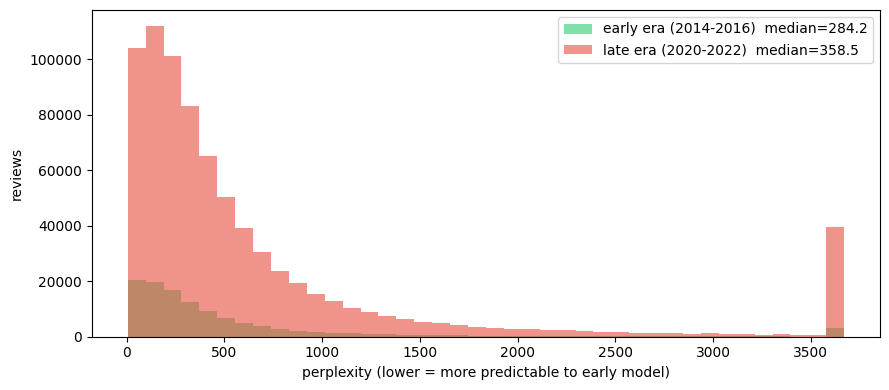


lifespan perplexity
training: 7,286  self test: 2,429  late test: 10,791
median self PPL : 650.7
median late PPL : 663.6
ratio           : 1.020
mann-whitney    : p=0.0190  (significant at alpha=0.05)


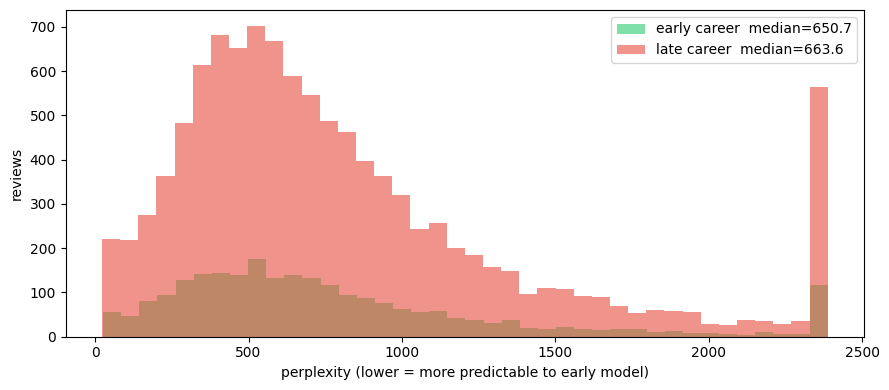


task                    ratio
------------------------------
temporal                1.261
lifespan                1.020


In [ ]:
print("temporal perplexity")
self_ppls_temp, late_ppls_temp, ratio_temp = compute_perplexity_analysis(
    early_era, late_era)
plot_perplexity(self_ppls_temp, late_ppls_temp,
                "early era (2014-2016)", "late era (2020-2022)",
                filename="ppl_temporal.png")

print("\nlifespan perplexity")
self_ppls_life, late_ppls_life, ratio_life = compute_perplexity_analysis(
    early_career, late_career)
plot_perplexity(self_ppls_life, late_ppls_life,
                "early career", "late career",
                filename="ppl_lifespan.png")

print(f"\n{'task':<20} {'ratio':>8}")
print("-" * 30)
print(f"{'temporal':<20} {ratio_temp:8.3f}")
print(f"{'lifespan':<20} {ratio_life:8.3f}")

In [ ]:
# trains a CBOW Word2Vec model on the full review corpus

def tokenize_corpus(df):
    # tokenizes all reviews into token lists for Word2Vec training
    # skips reviews with fewer than 2 tokens

    corpus = []
    skipped = 0

    t0 = time.time()

    for i, text in enumerate(df["text"].dropna()):
        toks = tokenize(text)

        if len(toks) >= 2:
            corpus.append(toks)
        else:
            skipped += 1
        if (i + 1) % 500_000 == 0:
            print(f"  {i+1:,} reviews processed ({time.time() - t0:.0f}s)")

    print(f"done: {len(corpus):,} kept, {skipped:,} skipped ({time.time() - t0:.0f}s)")
    return corpus


def train_word2vec(corpus, vector_size=100, window=5, min_count=5, workers=4, seed=42):
    # trains CBOW Word2Vec — faster than skip-gram, sufficient at this data scale
    # epochs=3 is enough for a corpus this size

    t0 = time.time()
    model = Word2Vec(
        sentences=corpus,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=0,
        epochs=3,
        workers=workers,
        seed=seed,
    )

    print(f"training complete ({time.time() - t0:.0f}s)  vocab: {len(model.wv):,} words")
    return model

In [ ]:
# saves the full model so it can be reloaded without retraining

def save_word2vec(model, path="word2vec.model"):
    model.save(path)
    print(f"model saved to {path}")


def load_word2vec(path="word2vec.model"):
    model = Word2Vec.load(path)
    print(f"model loaded from {path}  vocab: {len(model.wv):,} words")
    return model

In [ ]:
corpus = tokenize_corpus(amazon_df)
w2v = train_word2vec(corpus)
save_word2vec(w2v)

  500,000 reviews processed (20s)
  1,000,000 reviews processed (32s)
  1,500,000 reviews processed (41s)
  2,000,000 reviews processed (53s)
done: 2,427,132 kept, 65,667 skipped (60s)
training complete (204s)  vocab: 41,615 words
model saved to word2vec.model


In [ ]:
# building blocks used by all centroid and embedding analyses

def get_doc_vector(tokens, wv):
    # average Word2Vec vectors for a token list, None if no tokens in vocab

    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else None


def compute_centroid(df, wv):
    # mean document vector across all reviews in df, using tokens column

    vecs = []
    for tokens in df["tokens"].dropna():

        vec = get_doc_vector(tokens, wv)
        if vec is not None:
            vecs.append(vec)
    return np.mean(vecs, axis=0) if vecs else None


def cosine_distance(v1, v2):
    return 1.0 - np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)

In [ ]:
def compute_centroid_drift(df_a, df_b, wv):
    # cosine distance between centroids of two review groups
    # returns distance, centroid_a, centroid_b

    c_a = compute_centroid(df_a, wv)
    c_b = compute_centroid(df_b, wv)

    return cosine_distance(c_a, c_b), c_a, c_b


def compute_monthly_centroids(df, wv, start_year=2014, end_year=2022,
                              sample_per_month=3000, seed=42):
    # one centroid per calendar month, keyed by (year, month)
    # tokenizes on the fly since amazon_df has no tokens column
    # months with fewer than 50 reviews are skipped

    df = df.copy()
    df["year"] = pd.to_datetime(df["timestamp_sec"], unit="s").dt.year
    df["month"] = pd.to_datetime(df["timestamp_sec"], unit="s").dt.month
    df = df[df["year"].between(start_year, end_year)]

    rng = random.Random(seed)
    centroids = {}

    for (year, month), group in df.groupby(["year", "month"]):

        texts = group["text"].dropna().tolist()
        if len(texts) < 50:
            continue

        sample = rng.sample(texts, min(sample_per_month, len(texts)))
        vecs = [v for text in sample
                  for v in [get_doc_vector(tokenize(text), wv)] if v is not None]
        if vecs:
            centroids[(year, month)] = np.mean(vecs, axis=0)

    print(f"computed {len(centroids)} monthly centroids ({start_year}-{end_year})")
    return centroids


def compute_residual_drift(df_early, df_late, wv, monthly_centroids):
    # computes lifespan centroid distance before and after subtracting monthly centroid
    # subtracting the monthly centroid removes era-level vocabulary from each review,
    # isolating genuine career-stage drift from temporal confounding

    def get_residual_vecs(df):

        vecs = []
        for _, row in df.iterrows():

            vec = get_doc_vector(row["tokens"], wv)
            if vec is None:
                continue
            key = (pd.Timestamp(row["timestamp_sec"], unit="s").year,
                   pd.Timestamp(row["timestamp_sec"], unit="s").month)
            if key not in monthly_centroids:
                continue
            vecs.append(vec - monthly_centroids[key])

        return vecs

    raw_dist, _, _ = compute_centroid_drift(df_early, df_late, wv)

    res_early = get_residual_vecs(df_early)
    res_late = get_residual_vecs(df_late)
    c_e = np.mean(res_early, axis=0)
    c_l = np.mean(res_late,  axis=0)
    res_dist = cosine_distance(c_e, c_l)

    return raw_dist, res_dist

In [ ]:
print("computing temporal centroid drift...")
temporal_dist, c_temp_early, c_temp_late = compute_centroid_drift(early_era, late_era, w2v.wv)

print("computing lifespan centroid drift...")
lifespan_dist, c_life_early, c_life_late = compute_centroid_drift(early_career, late_career, w2v.wv)

print(f"\ntemporal centroid distance : {temporal_dist:.4f}")
print(f"lifespan centroid distance : {lifespan_dist:.4f}")

print("\ncomputing monthly centroids...")
monthly_centroids = compute_monthly_centroids(amazon_df, w2v.wv)

print("\ncomputing residual lifespan drift...")
raw_dist, res_dist = compute_residual_drift(early_career, late_career, w2v.wv, monthly_centroids)

print(f"\nraw lifespan distance      : {raw_dist:.4f}")
print(f"residual lifespan distance : {res_dist:.4f}")
print(f"temporal distance          : {temporal_dist:.4f}")

computing temporal centroid drift...
computing lifespan centroid drift...

temporal centroid distance : 0.0346
lifespan centroid distance : 0.0024

computing monthly centroids...
computed 108 monthly centroids (2014-2022)

computing residual lifespan drift...

raw lifespan distance      : 0.0024
residual lifespan distance : 0.0321
temporal distance          : 0.0346


In [ ]:
def sample_vectors(df, wv, sample_n=3000, seed=42):
    # samples reviews from df and returns document vectors using tokens column

    df = df.dropna(subset=["tokens"]).sample(min(sample_n, len(df)), random_state=seed)
    vecs = [v for tokens in df["tokens"] for v in [get_doc_vector(tokens, wv)] if v is not None]
    return np.array(vecs)


def sample_residual_vectors(df, wv, monthly_centroids, sample_n=3000, seed=42):
    # samples reviews and subtracts each review's monthly centroid vector

    df = df.dropna(subset=["tokens", "timestamp_sec"]).sample(
        min(sample_n, len(df)), random_state=seed)

    vecs = []

    for _, row in df.iterrows():

        vec = get_doc_vector(row["tokens"], wv)
        if vec is None:
            continue
        dt = pd.Timestamp(row["timestamp_sec"], unit="s")
        key = (dt.year, dt.month)
        if key not in monthly_centroids:
            continue
        vecs.append(vec - monthly_centroids[key])

    return np.array(vecs)


def plot_pca_two_groups(vecs_a, vecs_b, label_a, label_b, centroid_dist, ax,
                        color_a="#3498DB", color_b="#E74C3C"):
    # fits PCA on combined vectors and plots first 2 components
    # centroid markers are exact since PCA is a linear transform

    all_vecs = np.vstack([vecs_a, vecs_b])
    pca = PCA(n_components=2, random_state=42)
    proj = pca.fit_transform(all_vecs)
    proj_a = proj[:len(vecs_a)]
    proj_b = proj[len(vecs_a):]

    ax.scatter(proj_a[:, 0], proj_a[:, 1], c=color_a, label=label_a, s=4, alpha=0.3)
    ax.scatter(proj_b[:, 0], proj_b[:, 1], c=color_b, label=label_b, s=4, alpha=0.3)

    for proj_g, color in [(proj_a, color_a), (proj_b, color_b)]:

        cx, cy = proj_g[:, 0].mean(), proj_g[:, 1].mean()
        ax.scatter(cx, cy, c=color, s=250, edgecolors="black", linewidths=1.5, zorder=5)

    var = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({var[1]:.1%} variance)")
    ax.set_title(f"{label_a} vs {label_b}\ncentroid dist = {centroid_dist:.4f}",
                 fontweight="bold")

    ax.legend(markerscale=3, fontsize=9)

sampling temporal vectors...
sampling lifespan vectors...
sampling residual vectors...


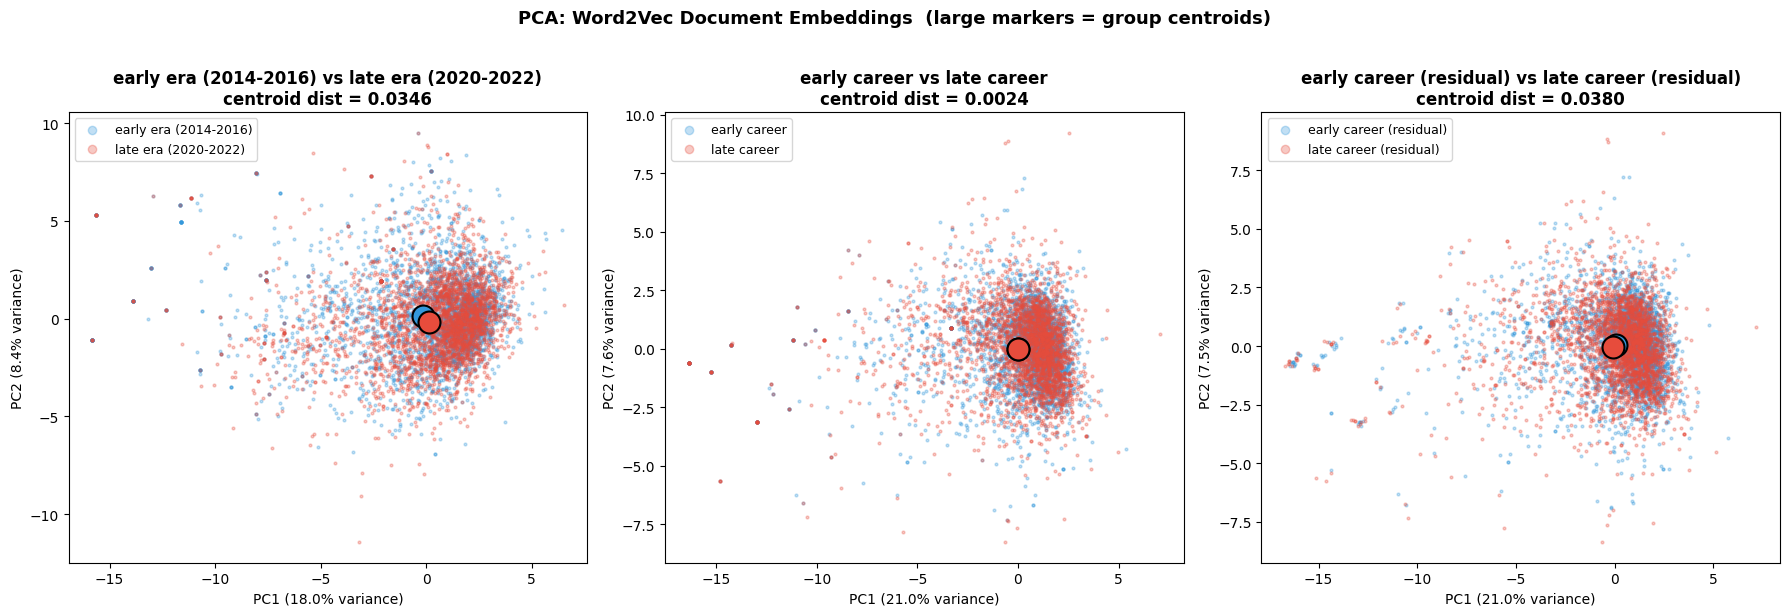


temporal          : 0.0346
lifespan raw      : 0.0024
lifespan residual : 0.0380


In [ ]:
# three panels: temporal drift, raw lifespan drift, residual lifespan drift

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

print("sampling temporal vectors...")
plot_pca_two_groups(
    sample_vectors(early_era,    w2v.wv),
    sample_vectors(late_era,     w2v.wv),
    "early era (2014-2016)", "late era (2020-2022)",
    temporal_dist, axes[0]
)

print("sampling lifespan vectors...")
plot_pca_two_groups(
    sample_vectors(early_career, w2v.wv),
    sample_vectors(late_career,  w2v.wv),
    "early career", "late career",
    lifespan_dist, axes[1]
)

print("sampling residual vectors...")
vecs_res_early = sample_residual_vectors(early_career, w2v.wv, monthly_centroids)
vecs_res_late = sample_residual_vectors(late_career,  w2v.wv, monthly_centroids)
res_centroid_dist = cosine_distance(vecs_res_early.mean(axis=0),
                                    vecs_res_late.mean(axis=0))
plot_pca_two_groups(
    vecs_res_early, vecs_res_late,
    "early career (residual)", "late career (residual)",
    res_centroid_dist, axes[2]
)

plt.suptitle("PCA: Word2Vec Document Embeddings  (large markers = group centroids)",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("pca_centroid_drift.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\ntemporal          : {temporal_dist:.4f}")
print(f"lifespan raw      : {lifespan_dist:.4f}")
print(f"lifespan residual : {res_centroid_dist:.4f}")

In [ ]:
def plot_monthly_drift_line(monthly_centroids, filename=None):
    # plots cosine distance between consecutive monthly centroids over time
    # highlights top drift months and shades the pandemic year

    keys = sorted(monthly_centroids.keys())

    dates = [pd.Timestamp(year=y, month=m, day=1) for y, m in keys]
    vecs = [monthly_centroids[k] for k in keys]
    distances = [cosine_distance(vecs[i], vecs[i + 1]) for i in range(len(vecs) - 1)]

    dist_series = pd.Series(distances, index=dates[1:])

    print("top 5 month-over-month drift:")

    for date, val in dist_series.nlargest(5).items():
        print(f"  {date.strftime('%Y-%m')} : {val:.5f}")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates[1:], distances, color="#3498DB", lw=1.5, alpha=0.7)
    ax.fill_between(dates[1:], distances, alpha=0.15, color="#3498DB")

    for date, val in dist_series.nlargest(3).items():

        ax.axvline(date, color="#E74C3C", lw=1.2, ls="--", alpha=0.6)
        ax.text(date, val, f" {date.strftime('%Y-%m')}",
                fontsize=8, color="#E74C3C", va="bottom")

    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
               alpha=0.08, color="#E74C3C", label="2020 (pandemic)")
    ax.set_xlabel("month")
    ax.set_ylabel("cosine distance from previous month")
    ax.set_title("month-over-month semantic drift in Amazon Fashion reviews",
                 fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")

    plt.show()
    return dist_series


def plot_monthly_trajectory_umap(monthly_centroids, wv, landmark_words,
                                  exclude_before="2015-01", seed=42, filename=None):
    # note: AI assistance used to generate UMAP visualizations
    # projects monthly centroids + word landmarks into 2D UMAP
    # path colored blue (early) to red (late), word landmarks shown in grey

    cutoff = pd.Timestamp(exclude_before)
    keys = sorted(k for k in monthly_centroids
                         if pd.Timestamp(year=k[0], month=k[1], day=1) >= cutoff)
    dates = [pd.Timestamp(year=y, month=m, day=1) for y, m in keys]
    cent_vecs = [monthly_centroids[k] for k in keys]

    valid_words = [w for w in landmark_words if w in wv]
    word_vecs = [wv[w] for w in valid_words]

    # stack centroids and word vectors for joint projection

    all_vecs = np.vstack(cent_vecs + word_vecs)
    n_cents = len(cent_vecs)

    reducer = umap.UMAP(n_components=2, random_state=seed, n_neighbors=15, min_dist=0.1)
    embedded = reducer.fit_transform(all_vecs)

    cent_coords = embedded[:n_cents]
    word_coords = embedded[n_cents:]

    n = len(dates)
    cmap = plt.cm.coolwarm
    colors = [cmap(i / (n - 1)) for i in range(n)]

    fig, ax = plt.subplots(figsize=(14, 10))

    # word landmarks
    ax.scatter(word_coords[:, 0], word_coords[:, 1],
               c="#BDC3C7", s=80, zorder=2, alpha=0.9)

    for i, word in enumerate(valid_words):
        ax.annotate(word, (word_coords[i, 0], word_coords[i, 1]),
                    fontsize=10, color="#555555",
                    xytext=(5, 5), textcoords="offset points")

    # path lines between consecutive centroids
    for i in range(n - 1):
        ax.plot([cent_coords[i, 0], cent_coords[i + 1, 0]],
                [cent_coords[i, 1], cent_coords[i + 1, 1]],
                color="#888888", lw=0.8, alpha=0.5, zorder=3)

    # centroid dots colored by time
    sc = ax.scatter(cent_coords[:, 0], cent_coords[:, 1],
                    c=range(n), cmap="coolwarm", s=40, zorder=4,
                    alpha=0.9, edgecolors="none")

    # label January of each year for orientation
    for i, (date, coord) in enumerate(zip(dates, cent_coords)):
        if date.month == 1:
            ax.annotate(str(date.year), coord, fontsize=10, fontweight="bold",
                        color=colors[i], xytext=(6, 6), textcoords="offset points")

    # mark pandemic months
    pandemic_idx = [i for i, d in enumerate(dates)
                    if d.year == 2020 and d.month in [3, 4]]

    if pandemic_idx:
        for idx in pandemic_idx:
            ax.scatter(*cent_coords[idx], s=120, zorder=6,
                       edgecolors="black", facecolors="none", linewidths=1.5)
        ax.annotate("COVID-19\n(Mar-Apr 2020)", cent_coords[pandemic_idx[0]],
                    fontsize=9, color="black", xytext=(10, -20),
                    textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", color="black", lw=1))

    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("time  (blue=2015, red=2022)", fontsize=10)
    cbar.set_ticks([])

    ax.set_title("monthly semantic drift trajectory  (2015-2022)\n"
                 "blue → red = early to late  |  grey = word landmarks",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


top 5 month-over-month drift:
  2014-07 : 0.16465
  2020-04 : 0.01160
  2016-12 : 0.00747
  2014-12 : 0.00699
  2019-06 : 0.00690


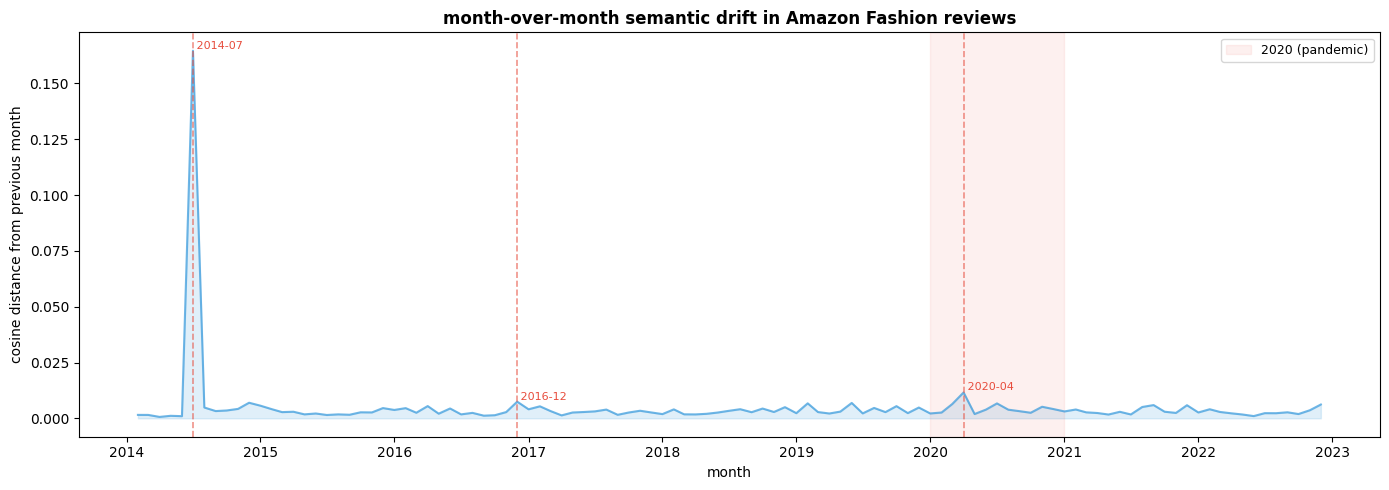

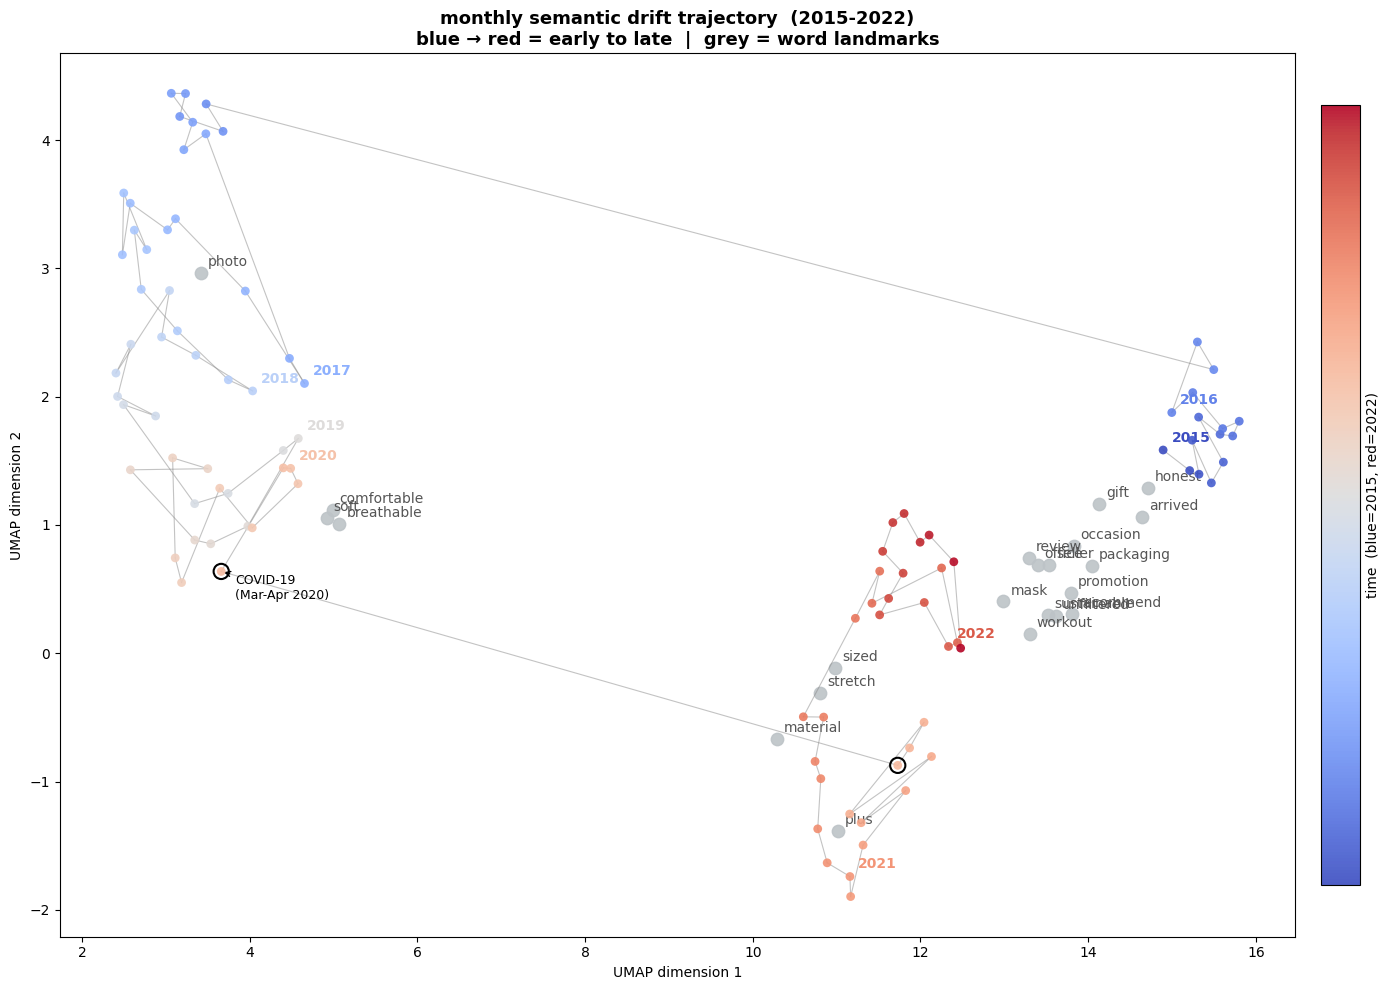

In [ ]:
# words drawn from DLA results, early and late era distinctive tokens, and some others

landmark_words = [
    "office", "review", "occasion", "gift",
    "seller", "photo", "mask", "breathable",
    "workout", "stretch", "arrived", "packaging",
    "material", "recommend", "sustainable", "sized",
    "plus", "comfortable", "honest", "unfiltered", "promotion",
    "soft"
]

monthly_drift_series = plot_monthly_drift_line(
    monthly_centroids, filename="monthly_drift_line.png")

plot_monthly_trajectory_umap(
    monthly_centroids, w2v.wv, landmark_words,
    filename="monthly_trajectory_umap.png")

In [ ]:
API_KEY = "DUMMY_KEY"
MODEL = "claude-sonnet-4-6"
SLEEP_SEC = 10
N_PER_CLASS = 25


def call_claude(prompt, max_tokens=150, retries=3):
    # calls Claude API with exponential backoff on rate limits and errors

    for attempt in range(retries):

        # error handling for too many requests
        try:
            resp = requests.post(
                "https://api.anthropic.com/v1/messages",
                headers={"x-api-key": API_KEY, "content-type": "application/json",
                         "anthropic-version": "2023-06-01"},
                json={"model": MODEL, "max_tokens": max_tokens,
                      "messages": [{"role": "user", "content": prompt}]},
                timeout=30,
            )

            if resp.status_code == 429:
                wait = max(int(resp.headers.get("retry-after", 30)), 5 * (2 ** attempt))
                print(f"  rate limited — waiting {wait}s (attempt {attempt+1}/{retries})")
                time.sleep(wait)
                continue

            if resp.status_code != 200:
                wait = 5 * (2 ** attempt)
                print(f"  HTTP {resp.status_code} — retrying in {wait}s")
                time.sleep(wait)
                continue
            return "".join(b["text"] for b in resp.json()["content"]
                           if b.get("type") == "text").strip()
        except requests.exceptions.Timeout:
            time.sleep(5 * (2 ** attempt))
        except Exception as e:
            print(f"  error: {e}")
            time.sleep(5 * (2 ** attempt))

    print("  all retries exhausted")
    return None


def parse_response(raw, valid_labels):
    # extracts label and justification from Claude's JSON response
    # falls back to scanning raw text if JSON parsing fails

    if not raw:
        return None, None

    try:
        start = raw.find("{")
        end = raw.rfind("}") + 1
        if start != -1 and end > start:
            obj = json.loads(raw[start:end])
            label = str(obj.get("label", "")).strip().lower()
            if label in valid_labels:
                return label, str(obj.get("justification", "")).strip()

    except json.JSONDecodeError:
        pass
    for lbl in valid_labels:
        if lbl in raw.lower():
            return lbl, raw
    return None, None

In [ ]:

def run_claude_task(df_pos, df_neg, label_pos, label_neg,
                    prompt_fn, task_name, out_csv, n_per_class=N_PER_CLASS):
    # samples balanced reviews, classifies with Claude, writes results to csv
    # returns results dataframe and metrics dict

    valid_labels = {label_pos, label_neg}

    pool_pos = df_pos[df_pos["text"].str.len() > 80]["text"].dropna()
    pool_neg = df_neg[df_neg["text"].str.len() > 80]["text"].dropna()
    n = min(len(pool_pos), len(pool_neg), n_per_class)

    texts = (pool_pos.sample(n, random_state=42).tolist() +
              pool_neg.sample(n, random_state=42).tolist())
    truths = [label_pos] * n + [label_neg] * n

    order = np.random.default_rng(42).permutation(len(texts))

    texts = [texts[i] for i in order]
    truths = [truths[i] for i in order]

    print(f"{task_name}  ({n} per class, {len(texts)} total)")

    preds, justifs = [], []
    for i, text in enumerate(texts):

        raw = call_claude(prompt_fn(text))
        time.sleep(SLEEP_SEC)
        pred, justif = parse_response(raw, valid_labels)
        preds.append(pred)
        justifs.append(justif)

        pd.DataFrame([{"text": text, "true": truths[i],
                       "pred": pred, "justification": justif}]).to_csv(
            out_csv, mode="a", header=(i == 0), index=False)

        if (i + 1) % 10 == 0:

            done = [p for p in preds if p]
            acc = sum(p == t for p, t in zip(preds, truths) if p) / max(len(done), 1)
            print(f"  [{i+1:3d}/{len(texts)}]  successful: {len(done)}  running acc: {acc:.1%}")

            if pred:
                print(f"    true: {truths[i]!r}  pred: {pred!r}")
                print(f"    justification: {justif[:120]}")

    results = pd.DataFrame({"text": texts, "true": truths,
                            "pred": preds, "justification": justifs})
    valid = results.dropna(subset=["pred"])

    acc = accuracy_score(valid["true"], valid["pred"])
    f1 = f1_score(valid["true"], valid["pred"], average="macro", zero_division=0)
    print(f"\naccuracy: {acc:.3f}   macro f1: {f1:.3f}   "
          f"(n={len(valid)}, failed={len(results)-len(valid)}, chance=0.500)")
    print(classification_report(valid["true"], valid["pred"],
                                labels=[label_pos, label_neg], digits=3))
    return results, {"acc": acc, "f1": f1}


def plot_confusion_matrices(results_temporal, metrics_temporal,
                            results_lifespan, metrics_lifespan, filename=None):
    # side-by-side confusion matrices for both classification tasks

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, results, metrics, title, labels in [
        (axes[0], results_temporal, metrics_temporal,
         "temporal\n(early era vs late era)", ["early", "late"]),
        (axes[1], results_lifespan, metrics_lifespan,
         "lifespan\n(early career vs late career)", ["early_career", "late_career"]),
    ]:

        valid = results.dropna(subset=["pred"])
        cm = confusion_matrix(valid["true"], valid["pred"], labels=labels)
        ConfusionMatrixDisplay(
            cm, display_labels=[l.replace("_", "\n") for l in labels]
        ).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{title}\nacc={metrics['acc']:.3f}  f1={metrics['f1']:.3f}  (chance=0.500)",
                     fontsize=11, fontweight="bold")

    plt.suptitle("Claude zero-shot classification results",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# note: AI assistance used to shorten and simplify prompts

def temporal_prompt(text):

    return f"""You are classifying Amazon Fashion reviews by the time period in which they were written.

Given the review below, determine whether it was written in the EARLY era (2014-2016) or the LATE era (2020-2022).

REVIEW:
\"\"\"{text[:500]}\"\"\"

Respond ONLY with a JSON object in this exact format:
{{"label": "early" or "late", "justification": "Two sentences explaining your reasoning."}}"""


def lifespan_prompt(text):

    return f"""You are classifying Amazon Fashion reviews by where they fall in a reviewer's career.

Given the review below, determine whether it was written EARLY in the reviewer's career (among their first reviews) or LATE in their career (among their last reviews before they stopped).

REVIEW:
\"\"\"{text[:500]}\"\"\"

Respond ONLY with a JSON object in this exact format:
{{"label": "early_career" or "late_career", "justification": "Two sentences explaining your reasoning."}}"""


results_temporal, metrics_temporal = run_claude_task(
    early_era, late_era, "early", "late",
    temporal_prompt, "temporal", "claude_temporal_results.csv")

results_lifespan, metrics_lifespan = run_claude_task(
    early_career, late_career, "early_career", "late_career",
    lifespan_prompt, "lifespan", "claude_lifespan_results.csv")

plot_confusion_matrices(results_temporal, metrics_temporal,
                        results_lifespan, metrics_lifespan,
                        filename="claude_confusion_matrices.png")

print(f"\n{'task':<35} {'accuracy':>9} {'macro f1':>9}")
print("-" * 55)

print(f"{'claude temporal (zero-shot)':<35} {metrics_temporal['acc']:9.3f} {metrics_temporal['f1']:9.3f}")
print(f"{'claude lifespan (zero-shot)':<35} {metrics_lifespan['acc']:9.3f} {metrics_lifespan['f1']:9.3f}")
print(f"{'tfidf temporal':<35} {metrics_temp['acc']:9.3f} {metrics_temp['f1']:9.3f}")
print(f"{'tfidf lifespan':<35} {metrics_life['acc']:9.3f} {metrics_life['f1']:9.3f}")
print(f"\nchance baseline: 0.500")

NameError: name 'run_claude_task' is not defined

counting tokens:   0%|          | 0/98294 [00:00<?, ?it/s]

departed users     : 13,814
total reviews      : 98,294
total tokens       : 4,364,528
avg tokens/review  : 44.4

reviews per user   : mean=7.1  median=6.0  std=5.1
lifespan (days)    : mean=1000  median=911  std=706

rating distribution:
  1 star : 7,395  (7.5%)
  2 star : 6,338  (6.4%)
  3 star : 11,306  (11.5%)
  4 star : 18,673  (19.0%)
  5 star : 54,582  (55.5%)


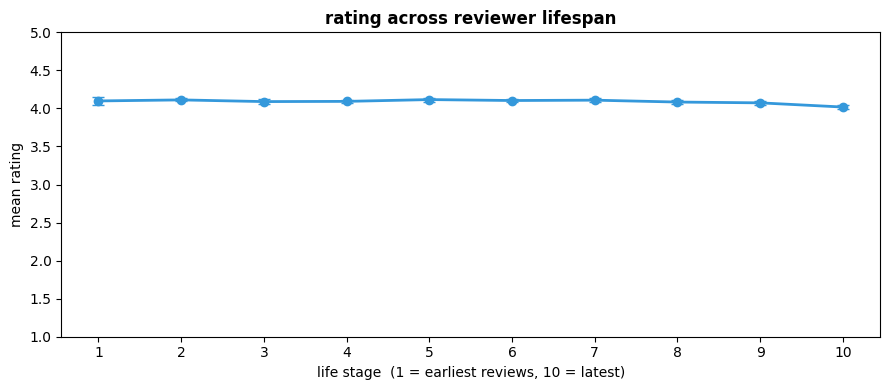

In [ ]:
# descriptive stats for the departed user population and rating trajectory

def print_departed_stats(user_df, df_dep):
    # prints token count, review count, lifespan, and rating distribution
    # for the departed user population

    dep = user_df[user_df["departed"] == True]
    total_tokens = count_tokens(df_dep)

    rc = df_dep.groupby("user_id").size()
    ls = dep["lifespan_days"]

    print(f"departed users     : {dep['user_id'].nunique():,}")
    print(f"total reviews      : {len(df_dep):,}")
    print(f"total tokens       : {total_tokens:,}")
    print(f"avg tokens/review  : {total_tokens / len(df_dep):.1f}")
    print(f"\nreviews per user   : mean={rc.mean():.1f}  median={rc.median():.1f}  std={rc.std():.1f}")
    print(f"lifespan (days)    : mean={ls.mean():.0f}  median={ls.median():.0f}  std={ls.std():.0f}")
    print(f"\nrating distribution:")

    for star, count in df_dep["rating_int"].value_counts().sort_index().items():
        print(f"  {star} star : {count:,}  ({100 * count / len(df_dep):.1f}%)")


def plot_rating_by_lifestage(df_dep, filename=None):
    # mean rating across life stage bins with 95% CI
    # shows whether reviewers become more or less positive over their career

    stage_stats = (df_dep.groupby("life_stage_bin")["rating_int"]
                         .agg(["mean", "sem"])
                         .reset_index())

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.errorbar(stage_stats["life_stage_bin"], stage_stats["mean"],
                yerr=1.96 * stage_stats["sem"],
                fmt="o-", color="#3498DB", lw=2, capsize=4, markersize=6)

    ax.set_xlabel("life stage  (1 = earliest reviews, 10 = latest)")
    ax.set_ylabel("mean rating")
    ax.set_title("rating across reviewer lifespan", fontweight="bold")
    ax.set_xticks(range(1, 11))
    ax.set_ylim(1, 5)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


print_departed_stats(user_df, df_dep)
plot_rating_by_lifestage(df_dep, filename="rating_by_lifestage.png")